<a href="https://colab.research.google.com/github/jgalcivar23-pixel/Shield_Cac/blob/main/Shield_Agro_Cacao_Intelligence.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# Shield-Agro Precisión | Cacao Intelligence
# Random Forest - Monilia & Phytophthora | Esmeraldas 2024-2025
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
from datetime import datetime

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score
)

# ── 1. CARGA ──────────────────────────────────────────────
df = pd.read_excel("/content/Resultados_ShieldAgro (1).xlsx")

# The 'Fecha' column is already parsed as datetime by pandas, so this conversion is no longer needed.
# If it were numeric serial dates, the previous line would likely need adjustment or a direct conversion of the numeric column.
# df["Fecha"] = pd.to_datetime(df["Fecha"], origin="1899-12-30", unit="D")
df = df.sort_values("Fecha").reset_index(drop=True)

print(f"Shape: {df.shape}")
print(df["Alerta_Monilia"].value_counts())
print(df["Alerta_Phytophthora"].value_counts())

Shape: (457, 27)
Alerta_Monilia
MEDIO    285
ALTO     172
Name: count, dtype: int64
Alerta_Phytophthora
BAJO     282
ALTO     117
MEDIO     58
Name: count, dtype: int64


In [ ]:
# ── 2. FEATURES & TARGETS ─────────────────────────────────
FEATURES = [
    "humedad", "Temperatura Media", "Temperatura Minima",
    "Temperatura Maxima", "radiacion", "viento",
    "presion superficial", "precipitacion",
    "VPD", "Delta_Temp", "GDA_diario", "GDA_Acumulado",
    "NDVI_Sentinel", "REIP_Sentinel", "NDWI_Sentinel"
]

# ── Encoders ──
le_m = LabelEncoder()
le_p = LabelEncoder()

df["target_monilia"]     = le_m.fit_transform(df["Alerta_Monilia"])
df["target_phytophthora"] = le_p.fit_transform(df["Alerta_Phytophthora"])

X = df[FEATURES]
y_m = df["target_monilia"]
y_p = df["target_phytophthora"]

print("Clases Monilia:", le_m.classes_)
print("Clases Phytophthora:", le_p.classes_)

Clases Monilia: ['ALTO' 'MEDIO']
Clases Phytophthora: ['ALTO' 'BAJO' 'MEDIO']


In [ ]:
# ── 3. TRAIN/TEST SPLIT ───────────────────────────────────
# Sin shuffle (respeta orden temporal)
split_idx = int(len(df) * 0.80)
X_train, X_test   = X.iloc[:split_idx], X.iloc[split_idx:]
ym_train, ym_test = y_m.iloc[:split_idx], y_m.iloc[split_idx:]
yp_train, yp_test = y_p.iloc[:split_idx], y_p.iloc[split_idx:]

print(f"Train: {len(X_train)} | Test: {len(X_test)}")

Train: 365 | Test: 92


In [ ]:
# ── 4. MODELOS ────────────────────────────────────────────
rf_m = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=3,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_p = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=3,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_m.fit(X_train, ym_train)
rf_p.fit(X_train, yp_train)
print("✅ Modelos entrenados")

✅ Modelos entrenados



📊 Monilia
              precision    recall  f1-score   support

        ALTO       0.95      1.00      0.97        36
       MEDIO       1.00      0.96      0.98        56

    accuracy                           0.98        92
   macro avg       0.97      0.98      0.98        92
weighted avg       0.98      0.98      0.98        92



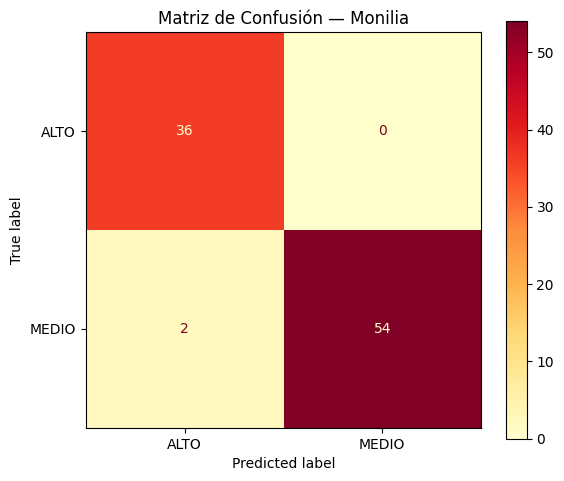


📊 Phytophthora
              precision    recall  f1-score   support

        ALTO       0.91      0.94      0.92        31
        BAJO       1.00      0.93      0.96        44
       MEDIO       0.74      0.82      0.78        17

    accuracy                           0.91        92
   macro avg       0.88      0.90      0.89        92
weighted avg       0.92      0.91      0.92        92



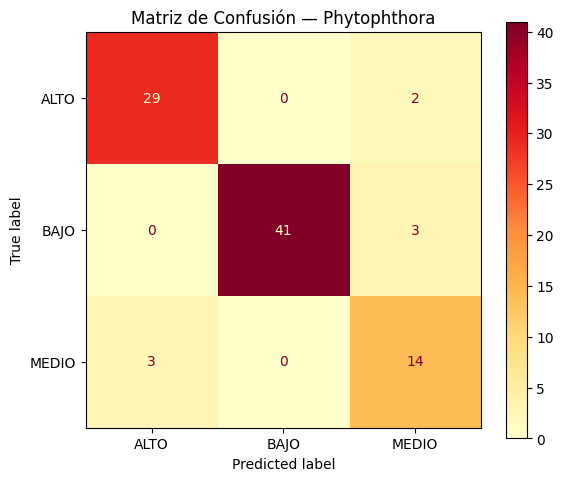

In [ ]:
# ── 5. EVALUACIÓN ─────────────────────────────────────────
def evaluar(model, X_test, y_test, le, nombre):
    y_pred = model.predict(X_test)
    print(f"\n{'='*50}")
    print(f"📊 {nombre}")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(ax=ax, cmap="YlOrRd")
    ax.set_title(f"Matriz de Confusión — {nombre}")
    plt.tight_layout()
    plt.savefig(f"cm_{nombre.lower().replace(' ', '_')}.png", dpi=150)
    plt.show()

evaluar(rf_m, X_test, ym_test, le_m, "Monilia")
evaluar(rf_p, X_test, yp_test, le_p, "Phytophthora")

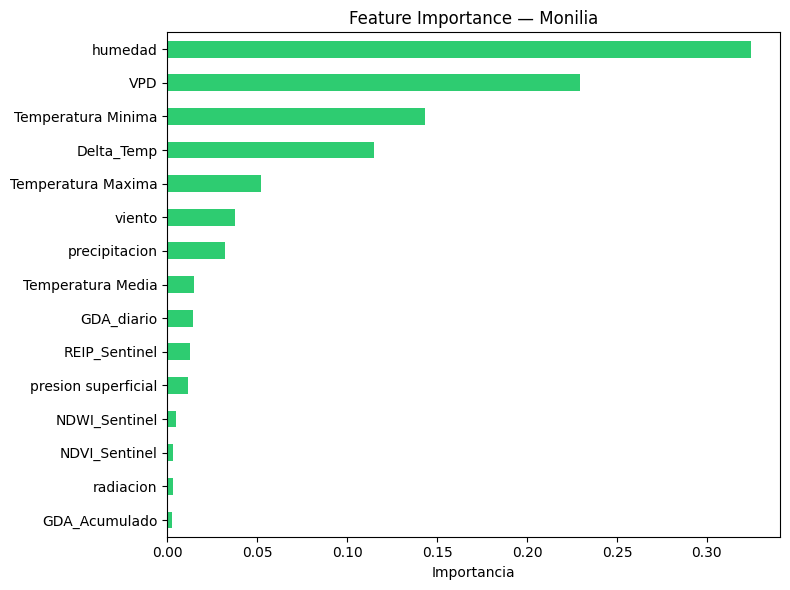

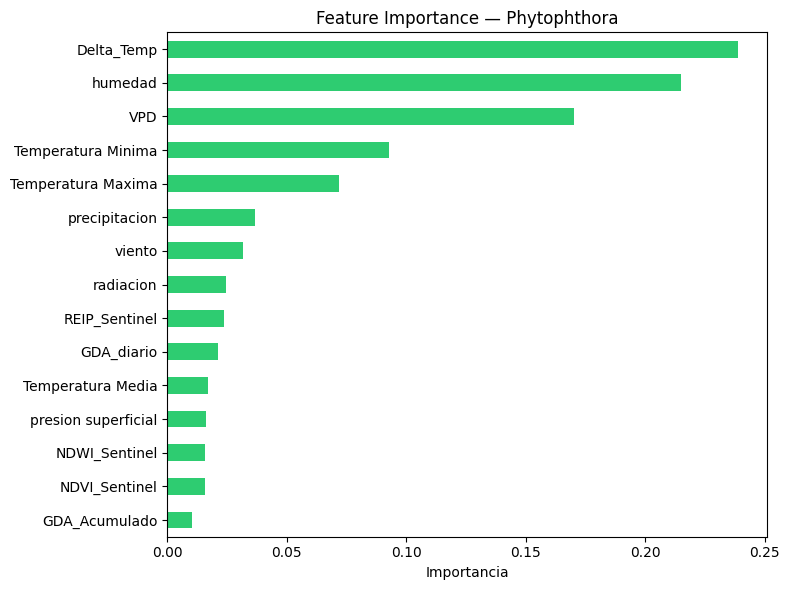

In [ ]:
# ── 6. IMPORTANCIA DE FEATURES ────────────────────────────
def plot_importances(model, features, nombre):
    imp = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(8, 6))
    imp.plot(kind="barh", color="#2ecc71", ax=ax)
    ax.set_title(f"Feature Importance — {nombre}")
    ax.set_xlabel("Importancia")
    plt.tight_layout()
    plt.savefig(f"importance_{nombre.lower()}.png", dpi=150)
    plt.show()
    return imp

imp_m = plot_importances(rf_m, FEATURES, "Monilia")
imp_p = plot_importances(rf_p, FEATURES, "Phytophthora")

In [ ]:
# ── 7. EXPORTAR MODELOS Y METADATA ────────────────────────
joblib.dump(rf_m, "rf_monilia.pkl")
joblib.dump(rf_p, "rf_phytophthora.pkl")
joblib.dump(le_m, "le_monilia.pkl")
joblib.dump(le_p, "le_phytophthora.pkl")

# Metadata para el dashboard
metadata = {
    "features": FEATURES,
    "clases_monilia": list(le_m.classes_),
    "clases_phytophthora": list(le_p.classes_),
    "n_train": int(len(X_train)),
    "n_test": int(len(X_test)),
    "fecha_entrenamiento": datetime.now().isoformat(),
    "importancia_monilia": imp_m.to_dict(),
    "importancia_phytophthora": imp_p.to_dict()
}

with open("model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("✅ Modelos exportados: rf_monilia.pkl | rf_phytophthora.pkl")
print("✅ Encoders: le_monilia.pkl | le_phytophthora.pkl")
print("✅ Metadata: model_metadata.json")

✅ Modelos exportados: rf_monilia.pkl | rf_phytophthora.pkl
✅ Encoders: le_monilia.pkl | le_phytophthora.pkl
✅ Metadata: model_metadata.json


In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.facecolor'] = '#0d1117'
matplotlib.rcParams['axes.facecolor'] = '#0d1117'
matplotlib.rcParams['text.color'] = 'white'
matplotlib.rcParams['axes.labelcolor'] = 'white'
matplotlib.rcParams['xtick.color'] = 'white'
matplotlib.rcParams['ytick.color'] = 'white'

df = pd.read_excel("/content/Resultados_ShieldAgro (1).xlsx")
# The 'Fecha' column is already parsed as datetime by pandas, so this conversion is no longer needed.
df = df.sort_values("Fecha").reset_index(drop=True)

/tmp/ipykernel_7118/3496676677.py:20: UserWarning:

Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.

/tmp/ipykernel_7118/3496676677.py:21: UserWarning:

Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.



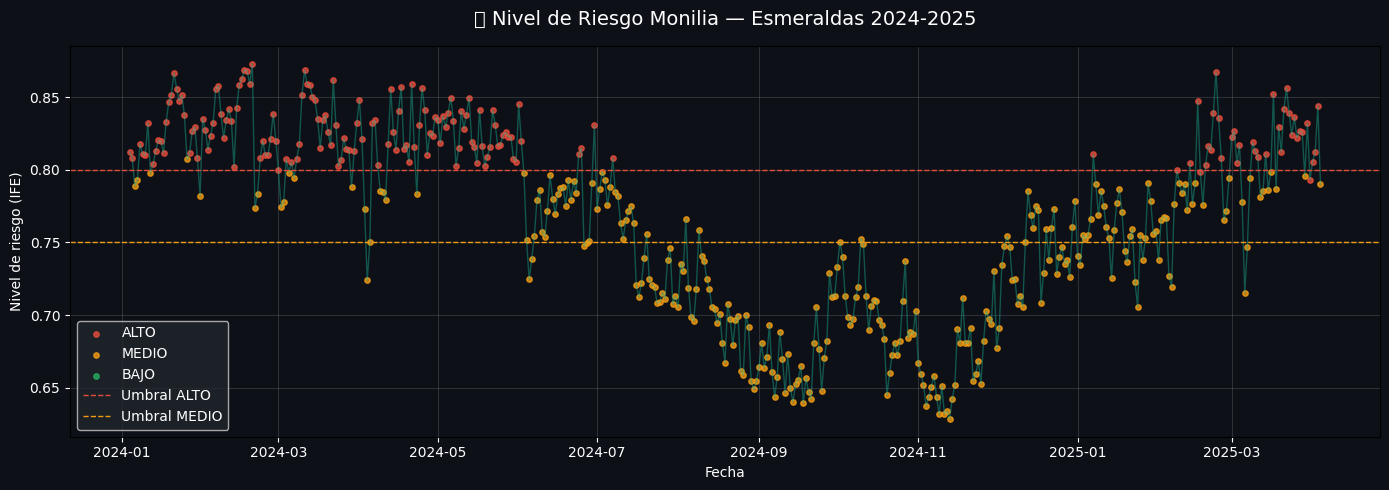

In [45]:
# Gráfico 1 — Tendencia de riesgo
fig, ax = plt.subplots(figsize=(14, 5))

colores = {"ALTO":"#e74c3c", "MEDIO":"#f39c12", "BAJO":"#27ae60"}
for nivel, color in colores.items():
    mask = df["Alerta_Monilia"] == nivel
    ax.scatter(df[mask]["Fecha"], df[mask]["IFE_Monilia"],
               color=color, label=nivel, s=15, alpha=0.8)

ax.plot(df["Fecha"], df["IFE_Monilia"],
        color="#1abc9c", linewidth=1, alpha=0.4)
ax.axhline(0.80, color="#e74c3c", linestyle="--", linewidth=1, label="Umbral ALTO")
ax.axhline(0.75, color="#f39c12", linestyle="--", linewidth=1, label="Umbral MEDIO")
ax.set_title("📈 Nivel de Riesgo Monilia — Esmeraldas 2024-2025",
             color="white", fontsize=14, pad=15)
ax.set_xlabel("Fecha")
ax.set_ylabel("Nivel de riesgo (IFE)")
ax.legend(facecolor="#21262d", labelcolor="white")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig("tendencia_riesgo.png", dpi=150, bbox_inches="tight")
plt.show()

/tmp/ipykernel_7118/742116668.py:15: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.

/tmp/ipykernel_7118/742116668.py:16: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.



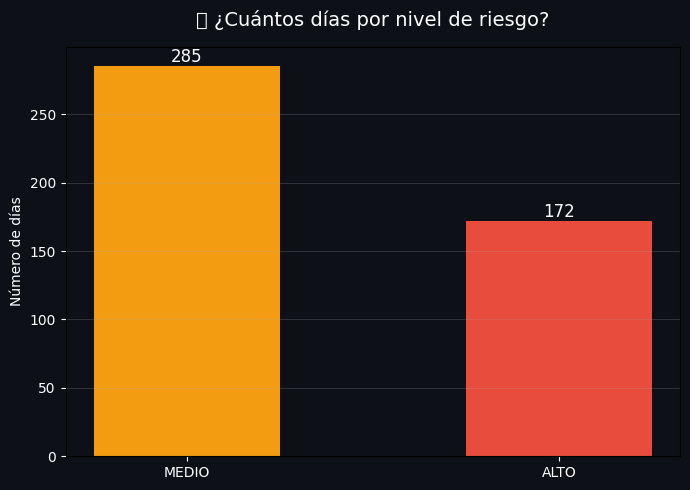

In [46]:
# Gráfico 2 — Conteo de alertas
conteo = df["Alerta_Monilia"].value_counts()
colores_barra = [{"ALTO":"#e74c3c","MEDIO":"#f39c12","BAJO":"#27ae60"}[k]
                 for k in conteo.index]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(conteo.index, conteo.values, color=colores_barra, width=0.5)
for bar, val in zip(bars, conteo.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            str(val), ha="center", color="white", fontsize=12)
ax.set_title("📊 ¿Cuántos días por nivel de riesgo?",
             color="white", fontsize=14, pad=15)
ax.set_ylabel("Número de días")
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.savefig("conteo_alertas.png", dpi=150, bbox_inches="tight")
plt.show()

/tmp/ipykernel_7118/584363628.py:13: UserWarning:

Glyph 127783 (\N{CLOUD WITH RAIN}) missing from font(s) DejaVu Sans.

/tmp/ipykernel_7118/584363628.py:14: UserWarning:

Glyph 127783 (\N{CLOUD WITH RAIN}) missing from font(s) DejaVu Sans.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 127783 (\N{CLOUD WITH RAIN}) missing from font(s) DejaVu Sans.



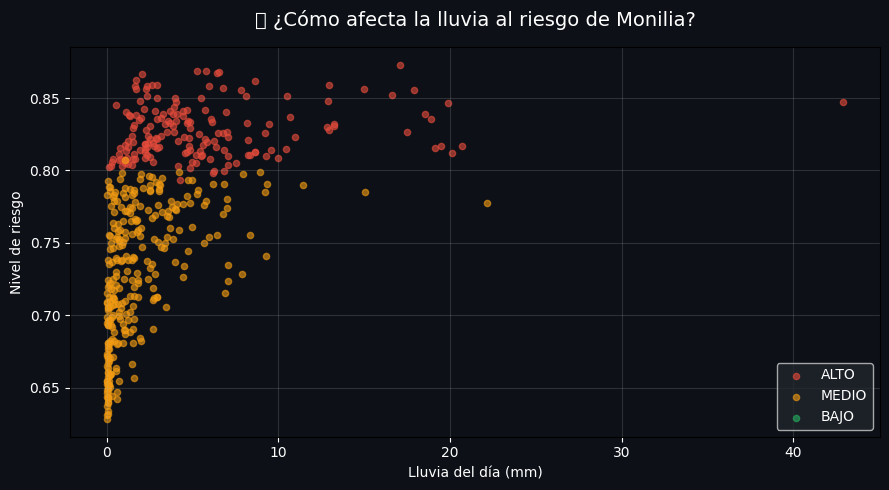

In [47]:
# Gráfico 3 — Lluvia vs Riesgo
fig, ax = plt.subplots(figsize=(9, 5))
for nivel, color in colores.items():
    mask = df["Alerta_Monilia"] == nivel
    ax.scatter(df[mask]["precipitacion"], df[mask]["IFE_Monilia"],
               color=color, label=nivel, alpha=0.6, s=20)
ax.set_title("🌧️ ¿Cómo afecta la lluvia al riesgo de Monilia?",
             color="white", fontsize=14, pad=15)
ax.set_xlabel("Lluvia del día (mm)")
ax.set_ylabel("Nivel de riesgo")
ax.legend(facecolor="#21262d", labelcolor="white")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig("lluvia_vs_riesgo.png", dpi=150, bbox_inches="tight")
plt.show()

/tmp/ipykernel_7118/221463169.py:13: UserWarning:

Glyph 127777 (\N{THERMOMETER}) missing from font(s) DejaVu Sans.

/tmp/ipykernel_7118/221463169.py:14: UserWarning:

Glyph 127777 (\N{THERMOMETER}) missing from font(s) DejaVu Sans.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 127777 (\N{THERMOMETER}) missing from font(s) DejaVu Sans.



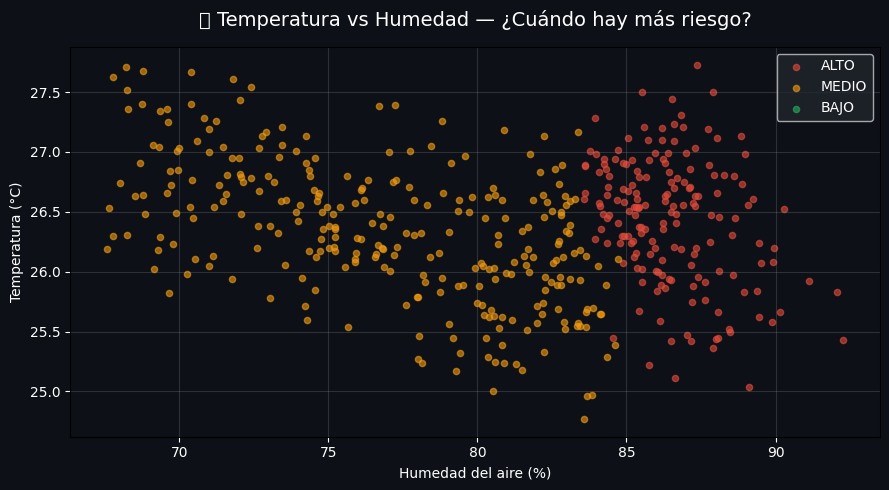

In [48]:
# Gráfico 4 — Temperatura vs Humedad
fig, ax = plt.subplots(figsize=(9, 5))
for nivel, color in colores.items():
    mask = df["Alerta_Monilia"] == nivel
    ax.scatter(df[mask]["humedad"], df[mask]["Temperatura Media"],
               color=color, label=nivel, alpha=0.6, s=20)
ax.set_title("🌡️ Temperatura vs Humedad — ¿Cuándo hay más riesgo?",
             color="white", fontsize=14, pad=15)
ax.set_xlabel("Humedad del aire (%)")
ax.set_ylabel("Temperatura (°C)")
ax.legend(facecolor="#21262d", labelcolor="white")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig("humedad_temperatura.png", dpi=150, bbox_inches="tight")
plt.show()